In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from functools import partial
from typing import NamedTuple, Callable

import numpy as np
import pandas as pd
from scipy import linalg, integrate, stats, special, optimize

import jax
from jax import scipy as jsp, numpy as jnp

import diffrax
import optimistix as optx
import equinox
import jaxopt

import seaborn as sns
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from power_duration import ode

jax.config.update('jax_enable_x64', True)

In [ ]:
gated_params = jnp.r_[
     1152,   283,    46,   2.0,    75, 
    20000,    85,   1.6,    59,    29
]

constant_gated = ode.gated_system()
adapt_gated = ode.gated_system(
    stepsize_controller=diffrax.PIDController(1e-5, 1e-5))

def interp_effort(t, y, args, **kwargs):
    (ts, Fs), params = args
    Pmax = params[0]
    R0 = y[..., 2]
    F = jnp.interp(t, ts, Fs, **kwargs).clip(0, 1) # between 0 and 1
    P = F * R0 * Pmax
    return P

pace_gated = adapt_gated.wrap(
    interp_effort, left='extrapolate', right='extrapolate'
)

In [ ]:
## Adding anerobic fatigue to dR2
def mod_fun(t, y, args):
    P, params = args
    Pmax, P2, M, t0, t1, t2, g, tG, a, tA = params
    G, A, R0, R1, *R2s = y

    # If R2 isn't passed then modelling quasi-steady state
    R2, = R2s if R2s else (1,)

    P = jnp.clip(P, 0, R0 * Pmax) + M  # Physiological power
    LP = R1 * G                        # Anerobic/Glycolytic power
    AP = R2 * A                        # Aerobic power

    dR0 = - (P - LP) / Pmax / t0       # Phosphagen depletion
    dR1 = - (LP - AP) / Pmax / t1      # Glycolytic depletion
    dR2 = - (AP - M) * (1 - R1) / P2 / t2         # Fatigue/glycogen exhaustion

    dG = (  # Glycolytic gate/activation
        g * P * (1 - R0)  # glycolytic pathway activated by ATP use
        * (1 - G / Pmax)  # sigmoidal activation
        - G               #
    ) / tG
    dA = (  # Aerobic gate/activation
        a * G * (1 - R1) # aerobic pathway activated by glycolytic pathway
        * (1 - A / P2)   # sigmoidal activation
        - A              #
    ) / tA

    if R2s:  # Modelling fatigue/glycogen exhaustion
        return jnp.r_[dG, dA, dR0, dR1, dR2].reshape(y.shape)
    else:    # Modelling quasi-steady state
        return jnp.r_[dG, dA, dR0, dR1].reshape(y.shape)


# params = jnp.r_[
#     1151.7 ,  298.35,   31.98,    2.53,   67.1 , 
#     1999.23,   85.97,   2.15,   32.95,   28.67
# ]
params = jnp.r_[
    1150.9, 290.73, 37.33, 1.18, 46.14, 
    2000.03, 83.97, 0.93, 61.52, 29.03
]
solver = diffrax.Tsit5()
root_solver = optx.Newton(1e-5, 1e-5)
constant_system = ode.ODESystem(
    terms=diffrax.ODETerm(mod_fun),
    event=diffrax.Event(ode._gated_condition, root_solver),
    solver=solver,
    stepsize_controller=diffrax.ConstantStepSize(),
    init=jax.jit(partial(ode._gated_init, solver=root_solver))
)
adapt_system = ode.ODESystem(
    terms=diffrax.ODETerm(mod_fun),
    event=diffrax.Event(ode._gated_condition, root_solver),
    solver=solver,
    stepsize_controller=diffrax.PIDController(1e-5, 1e-5),
    init=jax.jit(partial(ode._gated_init, solver=root_solver))
)

## Power Duration

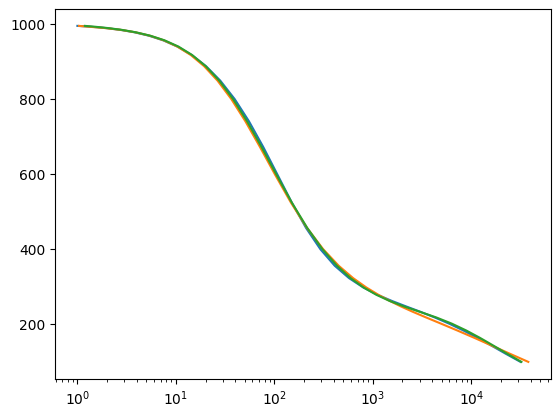

In [ ]:
def cp4_exp(t, CP, Pmax, logt1, logt2):
    t1 = jnp.exp(logt1)
    Wp = (Pmax - CP) * t1

    return (
        CP * jax.nn.sigmoid(logt2 - jnp.log(t))
        - Wp / t * jnp.expm1(-t / t1)
    )

cp4_params = jnp.r_[250, 1000, *np.log([60, 20_000])]
ts = np.logspace(0, 4.5, 32)
Ps = cp4_exp(ts, *cp4_params)
plt.semilogx(ts, Ps)

ode_ts = adapt_system.times_to_event(
    params, Ps, t0=0, t1=4e5, dt0=0.5, max_steps=40_000, throw=False
)
plt.plot(ode_ts, Ps)

ode_ts = adapt_gated.times_to_event(
    gated_params, Ps, t0=0, t1=4e5, dt0=0.5, max_steps=40_000, throw=False
)
plt.plot(ode_ts, Ps)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:30<00:00,  3.05s/it, loss=0.281]


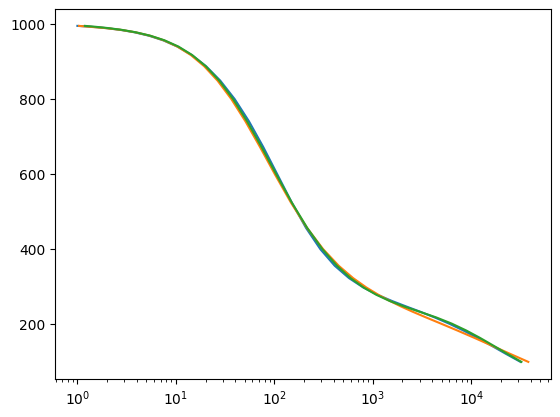

In [ ]:
## Fit ODE to power-duration data

loss = adapt_system.get_loss(
    t0=0, t1=1e5, dt0=0.25,
    throw=False,
    max_steps=int(1e6) + 1,
)
status = ode.OptStatus()
lbfgs = optx.LBFGS(
    rtol=1e-6, atol=1e-6,
    norm=optx.max_norm,
    verbose=status
)

m_prior = params
t_prior = jnp.r_[   0,   0,  1,  1, 1,     0, .1, 30, .1, 30] + 1e-6
param_names = "Pmax, P2, M, t0, t1, t2, g, tG, a, tA".split(", ")

args = (ts, Ps, t_prior, m_prior)
opt_kws = dict(throw=False, solver=lbfgs)

full_res = status.minimise(
    loss,
    y0=params,
    args=(ts, Ps, jnp.full_like(t_prior, 1e-6), m_prior),
    max_steps=10,
    **opt_kws
)

ts = np.logspace(0, 4.5, 32)
Ps = cp4_exp(ts, *cp4_params)
plt.semilogx(ts, Ps)

ode_ts = adapt_system.times_to_event(
    full_res.value, Ps, t0=0, t1=4e5, dt0=0.5, max_steps=40_000, throw=False
)
plt.plot(ode_ts, Ps)

ode_ts = adapt_gated.times_to_event(
    gated_params, Ps, t0=0, t1=4e5, dt0=0.5, max_steps=40_000, throw=False
)
plt.plot(ode_ts, Ps)

## Optimal Pacing

In [ ]:
pace_system = adapt_system.wrap(
    ode.interp_effort, left='extrapolate', right='extrapolate'
)
pacing = jax.jit(pace_system.pacing)

status = ode.OptStatus()
opt_kws = dict(
    throw=False,
    solver=optx.LBFGS(
        rtol=1e-6, atol=1e-6,
        norm=optx.max_norm,
        verbose=status
    )
)

optimise_pacing = partial(pace_system.optimise_pacing, optx=status, **opt_kws)

ts = np.linspace(0, 1000, 50)
pace_res = optimise_pacing(
    params, jnp.zeros_like(ts), ts, max_steps=10)

100%|██████████| 10/10 [00:09<00:00,  1.10it/s, loss=-6.57e+3]


In [ ]:
# Compare all-out, constant and optimised pacing

ts = np.linspace(0, 360, 50)

## All out effort, going at sigmoid(5) effort
allout = np.full_like(ts, 5)
Pallout = pacing(allout, ts, params)

## Get pacing for best constant power effort 
Pconst = adapt_system.event_time(params, ts[-1], max_steps=40_000)
const_sol = adapt_system.solve(
    params, Pconst, t0=0, t1=ts[-1],
    saveat=diffrax.SaveAt(dense=True), 
    max_steps=40_000,
)
ys = jax.vmap(const_sol.evaluate)(ts)
Fconst = jnp.clip(Pconst / ys[..., 2] / params[0], 1e-3, 0.9999)
logit_const = jsp.special.logit(Fconst)
Pc = pacing(logit_const, ts, params)

## Use constant pacing effort to initialize search for 'optimized' effort
pace_res = optimise_pacing(
    params, logit_const + 1., ts, max_steps=200)

Popt = pacing(pace_res.value, ts, params)
D = integrate.cumulative_trapezoid(Popt ** (1/3), ts, initial=0)
Dallout = integrate.cumulative_trapezoid(Pallout ** (1/3), ts, initial=0)
Dconst = integrate.cumulative_trapezoid(Pc ** (1/3), ts, initial=0)

plt.plot(ts, jax.nn.sigmoid(pace_res.value))
plt.plot(ts, jax.nn.sigmoid(allout))
plt.plot(ts, jax.nn.sigmoid(logit_const))
plt.ylim(0, 1)

plt.figure()
plt.semilogy(ts, Popt / Pconst)
plt.plot(ts, Pallout / Pconst)
plt.plot(ts, Pc / Pconst)

plt.figure()
Dmax = np.nanmax(D)
plt.plot(ts, (D - Dconst)       / Dmax, label='Opt')
plt.plot(ts, (Dallout - Dconst) / Dmax, label='all out')
plt.plot(ts, (Dconst - Dconst)  / Dmax, label='const')

D[-1], Dconst[-1], Dallout[-1]

  0%|          | 0/200 [00:00<?, ?it/s]

## Sensitivity analysis on pacing

/tmp/ipykernel_3939/2689610469.py:24: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


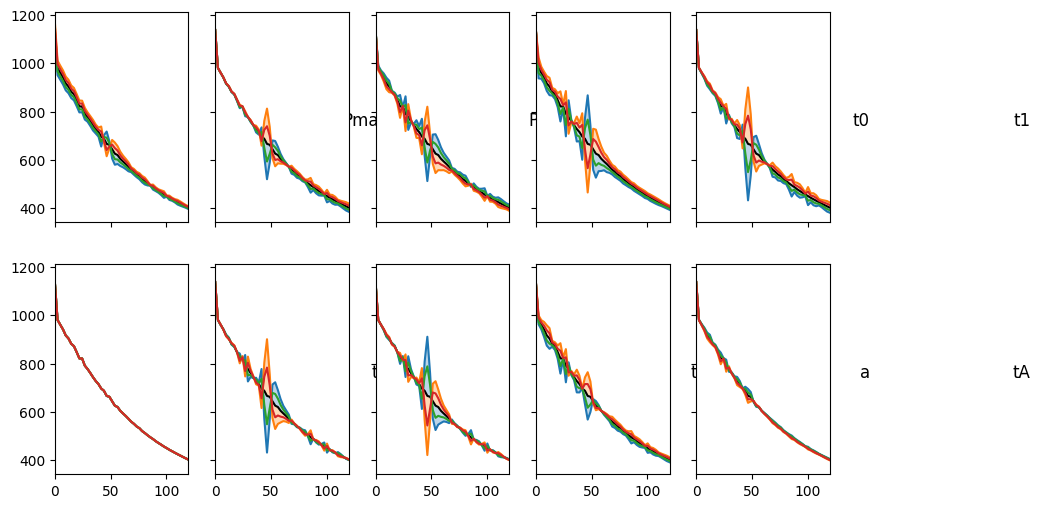

In [ ]:
Popt = pace_system.optimal_power(
    params, y0=pace_res.value, ts=ts, max_steps=100, **opt_kws)
J = jax.jacobian(pace_system.optimal_power)(
    params, y0=pace_res.value, ts=ts, max_steps=100, **opt_kws)

fig, axes = plt.subplots(
    2, 5, figsize=(10, 6), sharex=True, sharey=True)

f = Popt
for n, Ji, ax in zip(param_names, J.T, axes.flatten()):
    ji = Ji * 50 / (Ji.std() + 1.)
    
    ax.plot(ts, f, c='k')
    ax.fill_between(ts, f, f - ji, alpha=0.3)
    ax.fill_between(ts, f + ji, f, alpha=0.3)
    ax.plot(ts, f - ji)
    ax.plot(ts, f + ji)
    ax.plot(ts, f - ji * 0.5)
    ax.plot(ts, f + ji * 0.5)

    ax.text(300, 800, n, ha='right', va='top', fontsize=12)

ax.set_xlim(0, ts[-1])
fig.tight_layout()